In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal
from overview import FigureType, feature_overview

import numpy as np
import pandas as pd
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

from processors import temparature, season, month
from transforming import (
    Apply, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, roc_auc_score
import matplotlib.pyplot as plt


def checkup(estimator_base, X, y, folds=7):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict_proba(X.loc[train]).T[1]
        pv = estimator.predict_proba(X.loc[valid]).T[1]

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


df = pd.read_csv('data/train.csv', index_col='id')
test = pd.read_csv('data/test.csv', index_col='id')
test['rainfall'] = 0
CLASS_WEIGHTS = df.rainfall.value_counts() / df.shape[0]

__Pipelines__

In [59]:
ORIGIN = df.columns.to_list()
TEMPERATURES = ['mintemp', 'temparature', 'maxtemp']
SELECTION = [
    'sunshine_rate',
    'sunshine_div_temparature',
    'humidity_mul_cloud',
    'humidity_mul_sunshine',
    'short_weather_index',
    'wide_weather_index',
    'ct_month',
]

base_pipe = (
    # fix temperatures
    WithSelected(TEMPERATURES, prefix='')(
        Calc(lambda x: x.min(), to='_mintemp'),
        Calc(lambda x: x.max(), to='_maxtemp'),
        Calc(temparature, to='_temparature'),
        Select(TEMPERATURES, mode='drop'),
    ),
    Select(TEMPERATURES, mode='drop'),
    # abs dewpoint
    # Calc('abs(dewpoint)', to='dewpoint'),
    # some simple features
    Calc('_maxtemp - _mintemp', 'tempdelta'),
    Calc('dewpoint / _temparature', 'dewpoint_rate'),
    Calc('sunshine / _temparature', 'sunshine_div_temparature'),
    # Calc('windspeed * winddirection', to='windspeed_mul_winddirection'),
    Calc('cloud * windspeed', to='cloud_mul_windspeed'),
    # Calc('cloud / humidity', to='cloud_div_humidity'),
    Calc('humidity * cloud', to='humidity_mul_cloud'),
    Calc('humidity * sunshine', to='humidity_mul_sunshine'),
    Calc('cloud / (sunshine + 1e-5)', to='cloud_div_sunshine'),
    Calc('sunshine / (sunshine + cloud)', to='sunshine_rate'),
    Calc('0.4 * humidity + 0.3 * cloud + 0.3 * sunshine', to='short_weather_index'),
    Calc('0.3 * humidity + 0.25 * dewpoint_rate + 0.2 * windspeed + 0.2 * cloud', to='wide_weather_index'),

    Calc('np.sin(2 * np.pi * day / 365)', to='_day_sin'),
    Calc('np.cos(2 * np.pi * day / 365)', to='_day_cos'),

    # Calc('np.log(1 + windspeed_mul_winddirection)', to='log_windspeed_mul_winddirection'),
    Calc('np.log(1 + cloud_mul_windspeed)', to='log_cloud_mul_windspeed'),
    Calc('np.log(1 + humidity_mul_cloud)', to='log_humidity_mul_cloud'),
    Calc('np.log(1 + cloud_mul_windspeed)', to='log_cloud_mul_windspeed'),
    Calc('np.log(1 + humidity_mul_sunshine)', to='log_humidity_mul_sunshine'),
    Calc('np.log(1 + cloud_div_sunshine)', to='log_cloud_div_sunshine'),

    # Calc('', to=''),
    Fill(0),

    # calc month one hots
    Calc(month, to='ct_month'),
    # WithSelected(['ct_month'])(
    #     pre.OneHotEncoder(),
    # ),
    # calc seasons one hots
    Calc(season, to='ct_season'),
    # WithSelected(['ct_season'])(
    #     pre.OneHotEncoder(),
    # ),

    # groupings
    # day-to-day statistic
    # WithSelected(r'(?!ct_month|ct_season).*')(
    #     Group('day', 'mean', prefix='_day_mean_', include_target=True),
    # ),
    # month-to-month statistic
    WithSelected(r'(?!day|ct_season|.*rainfall).*')(
        Group('ct_month', 'mean', prefix='_month_mean_', include_target=False),
    ),
    # # statistic by season
    WithSelected(r'(?!day|ct_month_|_month_mean_).*')(
        Group('ct_season', 'mean', prefix='season_mean_'),
    ),

    # clusterize
    # WithSelected(None)(
    #     Fill('mean'),
    #     Apply(
    #         estimator=KMeans(n_clusters=3, random_state=17),
    #         locpipe=pre.StandardScaler(),
    #         to='ct_kmeans_cluster',
    #     ),
    #     Select(['ct_kmeans_cluster'], mode='keep'),
    #     TypeRecast(int)
    # ),

    # add mean for last 3 days
    # WithSelected(['pressure', 'humidity', 'cloud', 'sunshine', 'windspeed'], prefix='last_3days_mean_')(
    WithSelected(['cloud', 'sunshine'], prefix='last_3days_mean_')(
        Lag(3, 'mean'),
    ),
    # add for last day
    WithSelected(['cloud', 'sunshine', 'short_weather_index', 'wide_weather_index'], prefix='yesterday_')(
        Lag(1, 'mean'),
    ),
    # calc
    # Calc('yesterday_pressure - pressure', to='yesterday_pressure_delta'),
    # drop origin columns
    Select(ORIGIN, mode='drop'),
    # Select(SELECTION, mode='keep'),
    # Apply(
    #     estimator=LogisticRegression(
    #         solver='liblinear',
    #         max_iter=5000,
    #         penalty='l1',
    #         class_weight=CLASS_WEIGHTS.to_dict(),
    #         random_state=19
    #     ),
    #     # on=SELECTION,
    #     to='_rainfall_proba',
    #     as_proba=True
    # ),
    # recast one hots to int
    WithSelected(r'(.*_\d+|ct_.*)$')(
        TypeRecast(int)
    ),
)
sgd_pipe = (
    *base_pipe,
    WithSelected(r'(?!ct|day).*$')(
        KeepDataframe(pre.StandardScaler()),
    )
)
pipes = {
    'base': make_pipeline(*base_pipe),
    'sgd': make_pipeline(*sgd_pipe),
}

X: pd.DataFrame = pipes['base'].fit_transform(df.drop(columns='rainfall'), df.rainfall)     # type: ignore
SGD_X = pipes['sgd'].fit_transform(df.drop(columns='rainfall'), df.rainfall)
y = df.rainfall
SGD_X

,_mintemp,_maxtemp,_temparature,tempdelta,dewpoint_rate,sunshine_div_temparature,cloud_mul_windspeed,humidity_mul_cloud,humidity_mul_sunshine,cloud_div_sunshine,...,season_mean_log_humidity_mul_cloud,season_mean_log_humidity_mul_sunshine,season_mean_log_cloud_div_sunshine,season_mean_ct_month,last_3days_mean_cloud,last_3days_mean_sunshine,yesterday_cloud,yesterday_sunshine,yesterday_short_weather_index,yesterday_wide_weather_index
id,,,,,,,,,,,,,,,,,,,,,
0,-0.448184,-0.916756,-0.640635,-1.924540,0.863637,-0.629679,-0.184904,0.750543,-0.715426,-0.425587,...,0.572684,-1.576992,1.622707,-0.664525,0.976402,-0.992956,0.681269,-0.729417,0.713282,0.511795
1,-1.258430,-1.678817,-1.482526,-2.057039,0.944336,-0.975223,0.335084,1.295607,-1.064447,2.344957,...,0.572684,-1.576992,1.622707,-0.664525,0.976402,-0.992956,0.681269,-0.729417,0.713282,0.511795
2,-1.495575,-1.235758,-1.501660,0.394201,-2.449100,2.360809,-0.904078,-1.526162,1.205831,-0.425609,...,0.572684,-1.576992,1.622707,-0.664525,1.055925,-1.130648,0.847728,-1.032826,1.264792,1.173190
3,-1.041047,-1.466149,-1.176384,-1.990789,0.882495,-0.975223,1.842105,1.505035,-1.064447,2.466740,...,0.572684,-1.576992,1.622707,-0.664525,-0.030889,-0.229390,-1.593680,1.256535,-1.472278,-1.452991
4,-1.377003,-0.899033,-1.061581,1.255448,-2.957697,0.290862,-0.616257,-2.179248,-0.381723,-0.425607,...,0.572684,-1.576992,1.622707,-0.664525,0.154664,-0.367082,1.069675,-1.032826,1.440339,1.766819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,-0.606281,-0.562308,-0.640635,-0.069547,1.084468,-0.943810,0.282900,1.235534,-1.029071,-0.425343,...,0.572684,-1.576992,1.622707,-0.664525,0.870371,-0.942886,0.681269,-1.032826,0.138366,0.508429
2186,-1.159620,-1.607927,-1.291187,-2.123289,0.388594,-0.975223,1.543109,0.944539,-1.064447,2.253619,...,0.572684,-1.576992,1.622707,-0.664525,0.870371,-1.093095,0.681269,-1.005244,1.254552,1.180547
2187,-1.554862,-1.306647,-1.463392,0.327951,-0.671611,1.009777,0.992744,-0.029302,0.376131,-0.425606,...,0.572684,-1.576992,1.622707,-0.664525,0.976402,-1.393515,0.681269,-1.032826,0.899069,1.318268


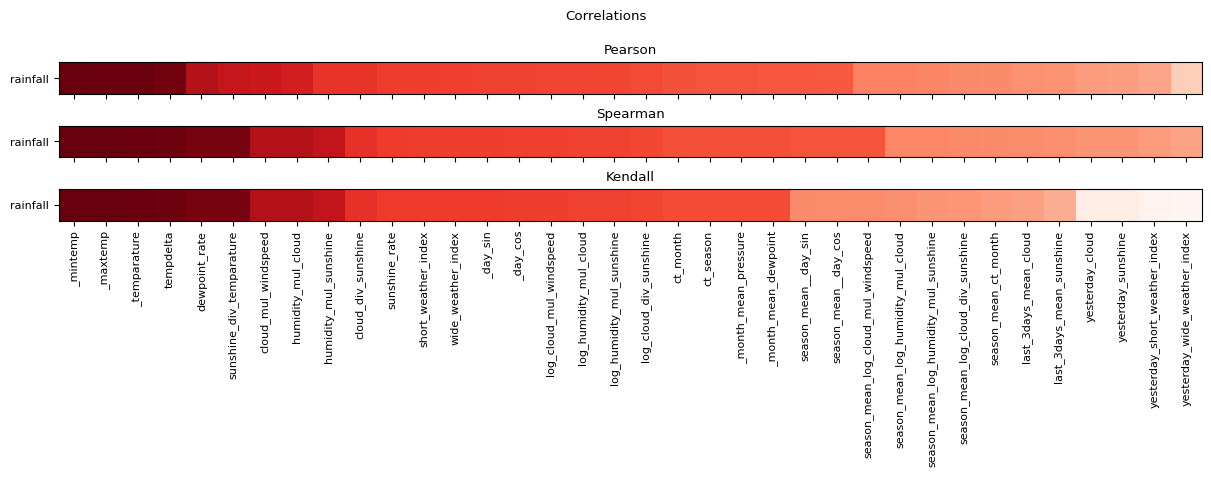

In [60]:
THRESHOLD = 0.075

data = X.copy()
labels = data.columns
data['rainfall'] = y

CORRELATIONS = ('pearson', 'spearman', 'kendall')
# CORRELATIONS = ('pearson', )
# drawing
fig, axes = plt.subplots(len(CORRELATIONS), 1, figsize=(12, 5), sharex=True)
fig.set_layout_engine('compressed')
fig.suptitle('Correlations')
for n, method in enumerate(CORRELATIONS):
    ax = axes[n] if len(CORRELATIONS) > 1 else axes
    ax.set_title(method.capitalize())
    rainfall_corr = data.corr(method)[['rainfall']].drop('rainfall').sort_values('rainfall', ascending=False)
    values = rainfall_corr.values.squeeze()
    filtered = (abs(values) > THRESHOLD)
    ax.imshow(values[filtered].reshape(1, -1), cmap='Reds')
    ax.set_xticks(range(len(labels[filtered])), labels=labels[filtered], rotation=90)
    ax.set_yticks([0], labels=['rainfall'])
plt.show()

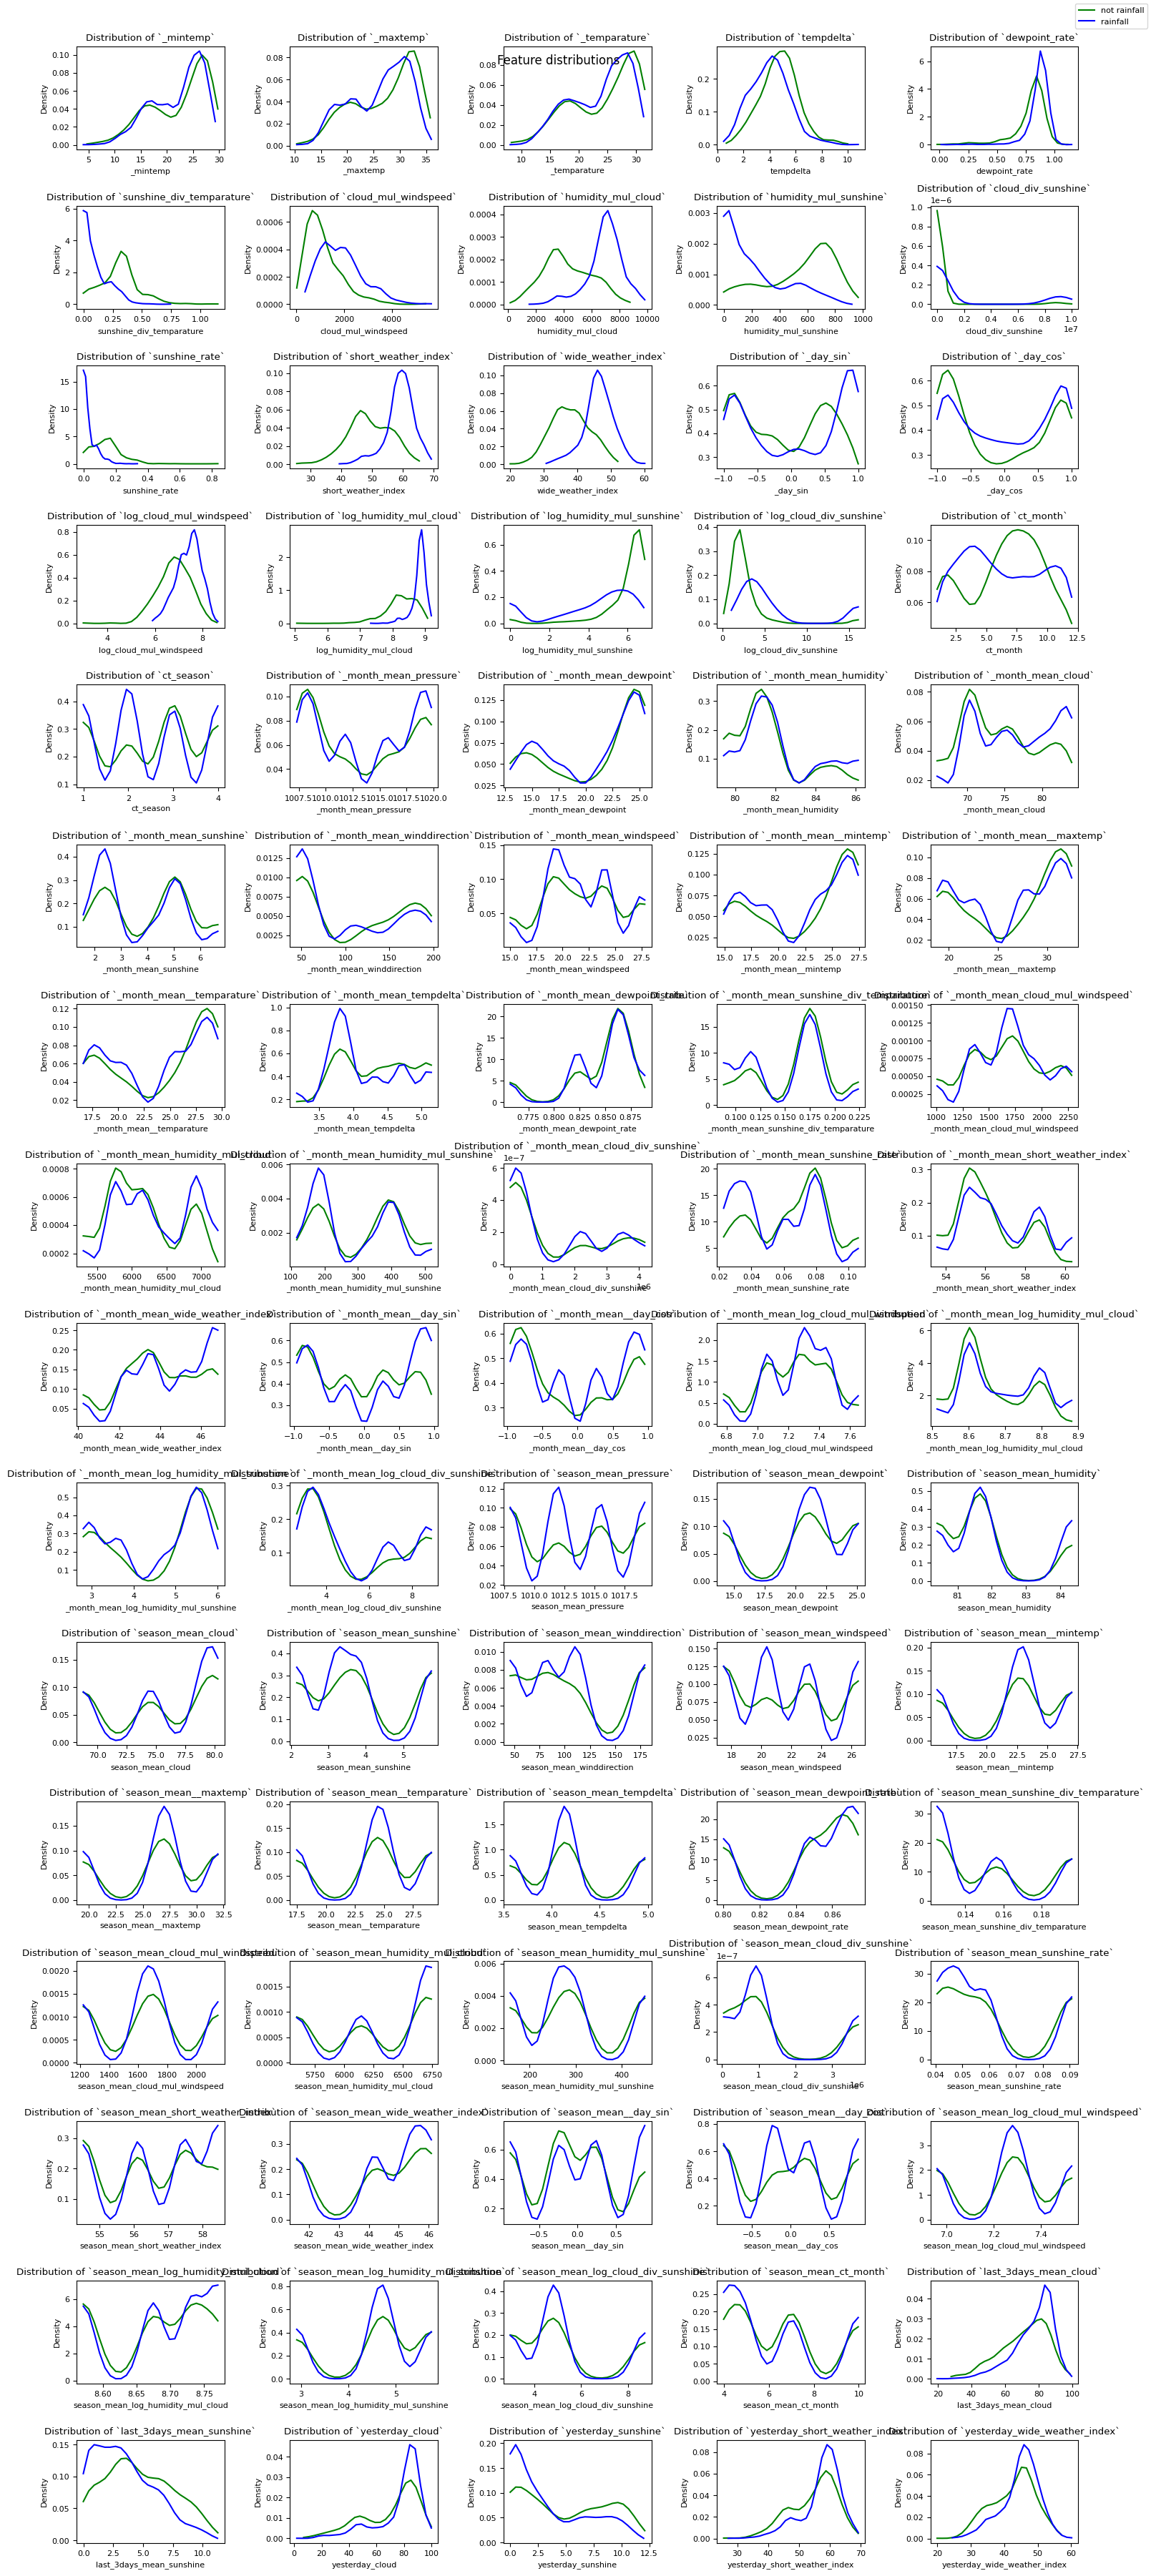

In [61]:
_X = X.copy()
_X['rainfall'] = y

COLUMNS = 5
ROWS = np.ceil((len(_X.columns) - 1) / COLUMNS).astype(int)
SIZE = (COLUMNS * 3, ROWS * 2.25)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')
for n, feature in enumerate(X.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if feature == 'rainfall':
        feature_overview(ax[row][col], _X.loc[X.rainfall == 0, feature].value_counts() / _X.shape[0], FigureType.BAR, color='green')
        feature_overview(ax[row][col], _X.loc[X.rainfall == 1, feature].value_counts() / _X.shape[0], FigureType.BAR, color='blue')
        continue
    feature_overview(ax[row][col], _X.loc[_X.rainfall == 0, feature], FigureType.DENSITY, bins=25, color='green')
    feature_overview(ax[row][col], _X.loc[_X.rainfall == 1, feature], FigureType.DENSITY, bins=25, color='blue')

fig.legend(['not rainfall', 'rainfall'])
plt.show()

In [117]:
', '.join(SELECTION)

'sunshine_rate, sunshine_div_temparature, humidity_mul_cloud, humidity_mul_sunshine, short_weather_index, wide_weather_index, ct_month'

__modeling__

In [62]:
estimator = SGDClassifier(
    loss='log_loss',
    # learning_rate='adaptive',
    # eta0=0.001,
    alpha=0.001,
    penalty='l1',
    max_iter=15000,
    n_jobs=-1,
    # early_stopping=True,
    class_weight=CLASS_WEIGHTS.to_dict(),
    shuffle=False,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
sgd = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.89665; TRAIN f1=0.89637 | VALID ROC AUC=0.89594; VALID f1=0.89231
Fold: 1; TRAIN ROC AUC=0.89617; TRAIN f1=0.89633 | VALID ROC AUC=0.89088; VALID f1=0.89804
Fold: 2; TRAIN ROC AUC=0.89920; TRAIN f1=0.89314 | VALID ROC AUC=0.87624; VALID f1=0.89143
Fold: 3; TRAIN ROC AUC=0.89408; TRAIN f1=0.89264 | VALID ROC AUC=0.89908; VALID f1=0.89484
Fold: 4; TRAIN ROC AUC=0.89227; TRAIN f1=0.89222 | VALID ROC AUC=0.92109; VALID f1=0.89615
Fold: 5; TRAIN ROC AUC=0.89757; TRAIN f1=0.89222 | VALID ROC AUC=0.88543; VALID f1=0.89788
Fold: 6; TRAIN ROC AUC=0.89785; TRAIN f1=0.89615 | VALID ROC AUC=0.87124; VALID f1=0.87925
MEAN: TRAIN ROC AUC=0.89626; TRAIN f1=0.89415 | VALID ROC AUC=0.89141; VALID f1=0.89284


In [63]:
estimator = LogisticRegression(
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
lin = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.90075; TRAIN f1=0.90489 | VALID ROC AUC=0.89434; VALID f1=0.90234
Fold: 1; TRAIN ROC AUC=0.89969; TRAIN f1=0.90365 | VALID ROC AUC=0.89687; VALID f1=0.90619
Fold: 2; TRAIN ROC AUC=0.90232; TRAIN f1=0.90500 | VALID ROC AUC=0.87508; VALID f1=0.90196
Fold: 3; TRAIN ROC AUC=0.89810; TRAIN f1=0.90689 | VALID ROC AUC=0.90051; VALID f1=0.90661
Fold: 4; TRAIN ROC AUC=0.89473; TRAIN f1=0.90400 | VALID ROC AUC=0.92444; VALID f1=0.90448
Fold: 5; TRAIN ROC AUC=0.90103; TRAIN f1=0.90358 | VALID ROC AUC=0.88309; VALID f1=0.90909
Fold: 6; TRAIN ROC AUC=0.90195; TRAIN f1=0.90719 | VALID ROC AUC=0.88279; VALID f1=0.89231
MEAN: TRAIN ROC AUC=0.89979; TRAIN f1=0.90503 | VALID ROC AUC=0.89387; VALID f1=0.90328


In [70]:
from modeling import EnsembleMeta

ensemble = EnsembleMeta(LogisticRegression, n_estimators=100, random_state=13)(
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
)
_ = checkup(ensemble, SGD_X, y)
ens = model = ensemble.fit(SGD_X, y, verbose=True)

Fold: 0; TRAIN ROC AUC=0.90079; TRAIN f1=0.90430 | VALID ROC AUC=0.89429; VALID f1=0.90234
Fold: 1; TRAIN ROC AUC=0.89969; TRAIN f1=0.90365 | VALID ROC AUC=0.89682; VALID f1=0.90619
Fold: 2; TRAIN ROC AUC=0.90229; TRAIN f1=0.90500 | VALID ROC AUC=0.87503; VALID f1=0.90196
Fold: 3; TRAIN ROC AUC=0.89809; TRAIN f1=0.90689 | VALID ROC AUC=0.90056; VALID f1=0.90661
Fold: 4; TRAIN ROC AUC=0.89471; TRAIN f1=0.90400 | VALID ROC AUC=0.92417; VALID f1=0.90448
Fold: 5; TRAIN ROC AUC=0.90101; TRAIN f1=0.90358 | VALID ROC AUC=0.88287; VALID f1=0.90909
Fold: 6; TRAIN ROC AUC=0.90200; TRAIN f1=0.90719 | VALID ROC AUC=0.88267; VALID f1=0.89231
MEAN: TRAIN ROC AUC=0.89980; TRAIN f1=0.90494 | VALID ROC AUC=0.89377; VALID f1=0.90328


100%|██████████| 100/100 [00:08<00:00, 11.87it/s]


In [65]:
estimator = KNeighborsClassifier(
    weights='uniform',
    algorithm='auto',
    n_neighbors=22,
    p=1,
    # leaf_size=60,
    n_jobs=-1,
)
_ = checkup(estimator, SGD_X, y)
knn = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.91368; TRAIN f1=0.91232 | VALID ROC AUC=0.87973; VALID f1=0.90650
Fold: 1; TRAIN ROC AUC=0.91099; TRAIN f1=0.91009 | VALID ROC AUC=0.89145; VALID f1=0.91023
Fold: 2; TRAIN ROC AUC=0.91281; TRAIN f1=0.91364 | VALID ROC AUC=0.87624; VALID f1=0.90574
Fold: 3; TRAIN ROC AUC=0.91288; TRAIN f1=0.91145 | VALID ROC AUC=0.89277; VALID f1=0.92149
Fold: 4; TRAIN ROC AUC=0.91015; TRAIN f1=0.91427 | VALID ROC AUC=0.89055; VALID f1=0.90428
Fold: 5; TRAIN ROC AUC=0.91412; TRAIN f1=0.91432 | VALID ROC AUC=0.87300; VALID f1=0.90984
Fold: 6; TRAIN ROC AUC=0.91363; TRAIN f1=0.91630 | VALID ROC AUC=0.87602; VALID f1=0.90389
MEAN: TRAIN ROC AUC=0.91261; TRAIN f1=0.91320 | VALID ROC AUC=0.88282; VALID f1=0.90885


Fold: 0; TRAIN ROC AUC=0.91155; TRAIN f1=0.89167 | VALID ROC AUC=0.88625; VALID f1=0.89083
Fold: 1; TRAIN ROC AUC=0.90868; TRAIN f1=0.89118 | VALID ROC AUC=0.90309; VALID f1=0.88090
Fold: 2; TRAIN ROC AUC=0.91103; TRAIN f1=0.89118 | VALID ROC AUC=0.88103; VALID f1=0.87500
Fold: 3; TRAIN ROC AUC=0.90686; TRAIN f1=0.89207 | VALID ROC AUC=0.90661; VALID f1=0.89716
Fold: 4; TRAIN ROC AUC=0.90372; TRAIN f1=0.89953 | VALID ROC AUC=0.92505; VALID f1=0.91183
Fold: 5; TRAIN ROC AUC=0.90980; TRAIN f1=0.89396 | VALID ROC AUC=0.88527; VALID f1=0.86486
Fold: 6; TRAIN ROC AUC=0.91026; TRAIN f1=0.89491 | VALID ROC AUC=0.88002; VALID f1=0.89565
MEAN: TRAIN ROC AUC=0.90884; TRAIN f1=0.89350 | VALID ROC AUC=0.89533; VALID f1=0.88803


100%|██████████| 20/20 [01:00<00:00,  3.01s/it]


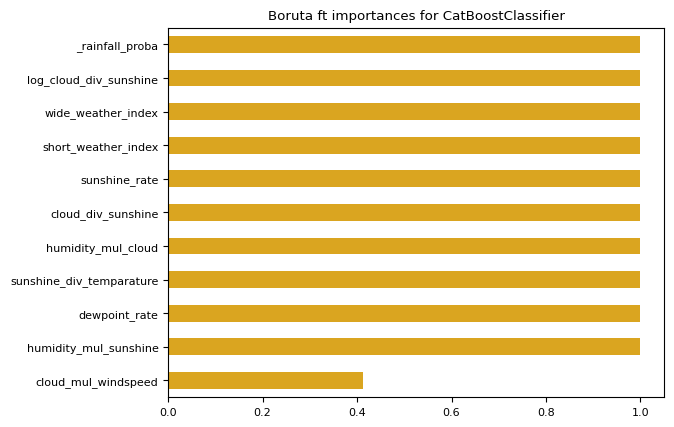

In [130]:
estimator = CatBoostClassifier(
    n_estimators=1500,
    # iterations=1500,
    learning_rate=0.001,
    depth=3,
    class_weights=CLASS_WEIGHTS,
    random_state=19,
    verbose=False,
    allow_writing_files=False,
)
_ = checkup(estimator, X, y, folds=7)
importances = boruta(X, y, estimator.copy(), seed=10, plot=True, alpha=0.99)
catboost = model = estimator.fit(X, y)

__submission__

In [66]:
# SGD
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = sgd.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

a680297b490f47fa92ac6225fbfe79f0


In [67]:
# logistic regression
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = lin.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

f81ef8c6aeaa48aaaddcdb73f0995103


In [71]:
# logistic regression ensemble
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = ens.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

f9d02c9d121c4d78af94035ea97c3b8e


In [72]:
# KNeighbours
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = knn.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

3f68538198664f9291e4c98f637ce572


In [62]:
# CatBoost
T = pipes['base'].transform(test.drop(columns='rainfall'))
rainfall = catboost.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

b5c1648db89343d191cbd8f500ebbc87


__NN approach__

In [73]:
import torch
import torch.optim as opt
import torch.utils.data
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [74]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y = None, size: int = 3):
        self.x = X.values.reshape(*X.shape, 1)
        self.y = y.values.reshape(-1, 1) if y is not None else None
        self.size = size

    def __getitem__(self, index):
        """Return item with N previous items"""
        x_bundle, y_bundle = [], []
        for step in range(self.size):
            if (idx := index - step) < 0:
                idx = index
            x_bundle.append(torch.as_tensor(self.x[idx], dtype=torch.float32))
        return (
            torch.concat(x_bundle, dim=-1).reshape(self.size, -1),
            torch.as_tensor(self.y[index], dtype=torch.float32) if self.y is not None else None
        )

    def __len__(self):
        return self.x.shape[0]

dataset = Dataset(SGD_X, y, size=3)
dataset[0][0].shape

torch.Size([3, 80])

In [ ]:
class ShowShape(torch.nn.Module):
    def forward(self, X, *args, **kw):
        print(f'{X.shape=}')
        return X


class Model:
    def __init__(
            self,
            days: int,
            features: int,
            hidden_channels: int | None = None,
            linear_channels: int = 64,
            criterion: torch.nn.modules.loss._Loss = torch.nn.BCELoss(),
            optimizer: type[torch.optim.Optimizer] = opt.Adam,
            device: Literal['cpu', 'cuda'] = 'cpu',
            **optimizer_params
    ):
        self.device = device
        self.days = days
        CHANNELS = hidden_channels or (days // 2 + (not days // 2))
        self.model = torch.nn.Sequential(
            # first conv
            torch.nn.Conv1d(days, CHANNELS, kernel_size=days),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=2),
            # linears
            torch.nn.Flatten(1),
            torch.nn.Linear(CHANNELS * ((features - days + 1) // 2), linear_channels // 2),

            # # first conv
            # torch.nn.Conv1d(days, CHANNELS, kernel_size=2 if days > 1 else 1),
            # torch.nn.ReLU(),
            # torch.nn.MaxPool1d(kernel_size=2),
            # # second conv
            # torch.nn.Conv1d(CHANNELS, days, kernel_size=days - 1),
            # torch.nn.ReLU(),
            # torch.nn.MaxPool1d(kernel_size=2),
            # # linears
            # torch.nn.Flatten(1),
            # torch.nn.Linear(days * ((((features - days + 1) // 2) - (days > 2)) // 2), linear_channels // 2),

            torch.nn.ReLU(),
            torch.nn.Dropout(0.25),
            torch.nn.Linear(linear_channels // 2, linear_channels // 4),
            torch.nn.ReLU(),
            torch.nn.Linear(linear_channels // 4, 1),
            torch.nn.Sigmoid(),
        )
        self.model.compile()
        self.optimizer = optimizer(self.model.parameters(), **optimizer_params)
        self.criterion = criterion

    def fit(self, X, y, epochs: int = 5, batch_size: int = 32, verbose: bool = True):
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
        # fit
        self.model.to(self.device)
        self.model.train()
        for ep in range(epochs):
            sum_loss, items = 0.0, 0
            if verbose:
                pbar = tqdm(enumerate(loader), total=len(loader), desc=f'Epoch {ep + 1}/{epochs}')
            else:
                pbar = enumerate(loader)
            for i, batch in pbar:
                inputs, labels = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                # calc loss
                sum_loss += loss.item()
                items += len(labels)
                if verbose and isinstance(pbar, tqdm):
                    pbar.set_postfix({'cumulative loss per item': sum_loss / items})
        self.model.eval()

    def predict_proba(self, X):
        assert self.model is not None, 'Model is not trained'
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=X.shape[0])
        predictions = self.model.forward(next(iter(loader))[0])
        return predictions.detach()

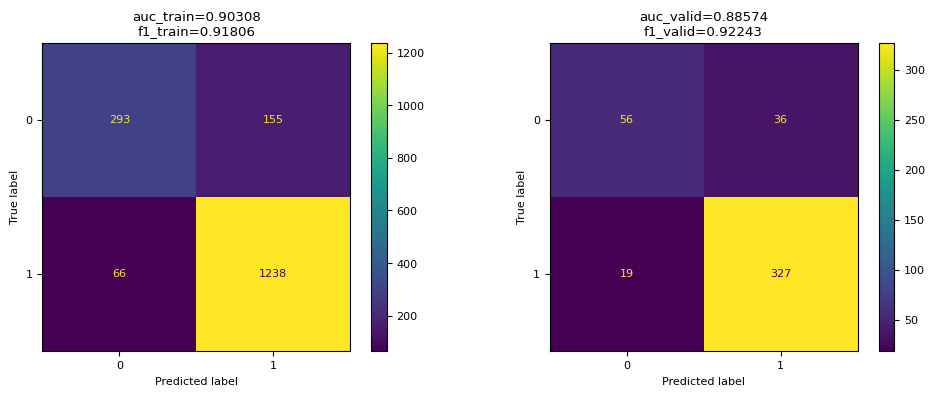

In [115]:
torch.manual_seed(11)
DAYS = 2
dataset = Dataset(SGD_X, y, size=DAYS)

model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    hidden_channels=4,
    linear_channels=256,
    criterion=torch.nn.BCELoss(),
    # criterion=torch.nn.HuberLoss(delta=0.8),
    lr=0.01,
)
X_train, X_valid, y_train, y_valid = train_test_split(SGD_X, y, test_size=0.2, shuffle=False, random_state=19)
model.fit(X_train, y_train, epochs=25, batch_size=1024, verbose=False)

# predicting
y_pred_train = model.predict_proba(X_train)
y_pred_valid = model.predict_proba(X_valid)
# scoring
auc_train = roc_auc_score(y_train, y_pred_train)
auc_valid = roc_auc_score(y_valid, y_pred_valid)
f1_train = f1_score(y_train, y_pred_train > 0.5)
f1_valid = f1_score(y_valid, y_pred_valid > 0.5)
# drawing
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train.numpy() > 0.5, ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_valid.numpy() > 0.5, ax=ax[1])
ax[0].set_title(f'{auc_train=:.5f}\n{f1_train=:.5f}')
ax[1].set_title(f'{auc_valid=:.5f}\n{f1_valid=:.5f}')
plt.show()

__NN cross validation__

In [116]:
def nn_checkup(estimator_base, X, y, folds=7, **fit_params):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train], **fit_params)

        pt = estimator.predict_proba(X.loc[train]).numpy()
        pv = estimator.predict_proba(X.loc[valid]).numpy()

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


torch.manual_seed(11)
_ = nn_checkup(model, SGD_X, y, epochs=10, batch_size=512, verbose=False)

Fold: 0; TRAIN ROC AUC=0.91475; TRAIN f1=0.91772 | VALID ROC AUC=0.87932; VALID f1=0.89901
Fold: 1; TRAIN ROC AUC=0.91355; TRAIN f1=0.91727 | VALID ROC AUC=0.88361; VALID f1=0.89507
Fold: 2; TRAIN ROC AUC=0.91511; TRAIN f1=0.92375 | VALID ROC AUC=0.87255; VALID f1=0.90283
Fold: 3; TRAIN ROC AUC=0.91666; TRAIN f1=0.92318 | VALID ROC AUC=0.88642; VALID f1=0.90581
Fold: 4; TRAIN ROC AUC=0.90882; TRAIN f1=0.92329 | VALID ROC AUC=0.91619; VALID f1=0.91532
Fold: 5; TRAIN ROC AUC=0.91842; TRAIN f1=0.91881 | VALID ROC AUC=0.87076; VALID f1=0.91393
Fold: 6; TRAIN ROC AUC=0.91572; TRAIN f1=0.92035 | VALID ROC AUC=0.89190; VALID f1=0.91837
MEAN: TRAIN ROC AUC=0.91472; TRAIN f1=0.92062 | VALID ROC AUC=0.88582; VALID f1=0.90719


__final fit__

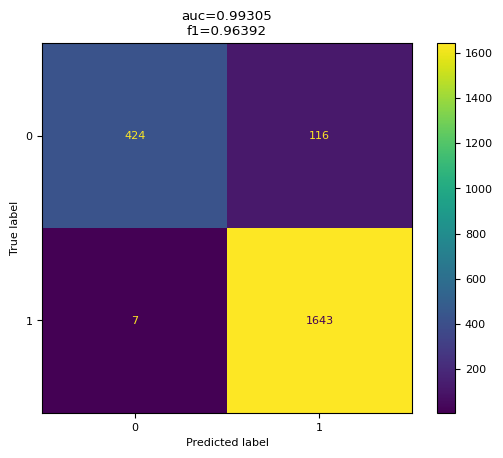

In [117]:
torch.manual_seed(11)
DAYS = 2
dataset = Dataset(SGD_X, y, size=DAYS)

cnn = model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    hidden_channels=4,
    linear_channels=256,
    criterion=torch.nn.BCELoss(),
    lr=0.01,
)
model.fit(SGD_X, y, epochs=250, batch_size=1024, verbose=False)

predictions = model.predict_proba(SGD_X)
auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions.numpy() > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [118]:
# CNN
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = cnn.predict_proba(T)

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

9b6fb95524d8444c9f23810a2a2fe931


__mix predictions__

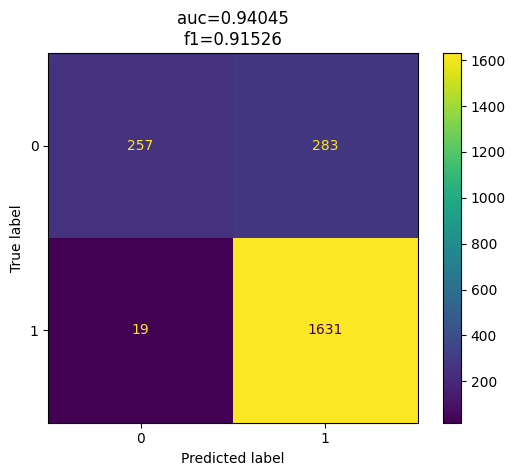

In [35]:
weights = np.array([0.3, 0.3, 0.15, 0.25]).reshape(4, 1)

predictions = sum(weights * np.array((
    sgd.predict_proba(SGD_X)[:, 1],
    lin.predict_proba(SGD_X)[:, 1],
    knn.predict_proba(SGD_X)[:, 1],
    # catboost.predict_proba(X)[:, 1],
    cnn.predict_proba(SGD_X).numpy()[:, 0],
)))

auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [36]:
T1 = pipes['base'].transform(test.drop(columns='rainfall'))
T2 = pipes['sgd'].transform(test.drop(columns='rainfall'))

rainfall = sum(weights * np.array((
    sgd.predict_proba(T2)[:, 1],
    lin.predict_proba(T2)[:, 1],
    knn.predict_proba(T2)[:, 1],
    # catboost.predict_proba(T1)[:, 1],
    cnn.predict_proba(T2).numpy()[:, 0]
)))
if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

c31d0ac049f346939ce388c0c5eaa524


In [ ]:
#